In [1]:
import pandas as pd
import numpy as np

# --- 1. 准备数据 (假设有3个方案，3个指标) ---
# 比如：指标1是正向的(越大越好)，指标2是负向的(越小越好)
data = pd.DataFrame({
    '指标A': [100, 90, 80], # 比如性能
    '指标B': [20, 30, 40],  # 比如价格(假设越低越好，需要处理)
    '指标C': [5, 5, 4]      # 比如重量
})

print("原始数据:\n", data)

# --- 2. 熵权法核心函数 (直接复制即可) ---
def cal_weight(df):
    # (1) 标准化 (把数据压缩到 0-1 之间，防止单位影响)
    # 这里默认都是“越大越好”。如果是“越小越好”，比赛时需要手动取倒数或者用 max-x 处理
    df = df.apply(lambda x: (x - x.min()) / (x.max() - x.min()))
    
    # (2) 计算比重
    # 加上 0.0001 是为了防止 log(0) 报错
    p = df / df.sum() + 0.0001 
    
    # (3) 计算熵值
    k = -1 / np.log(len(df))
    entropy = k * (p * np.log(p)).sum()
    
    # (4) 计算权重
    d = 1 - entropy
    weights = d / d.sum()
    
    return weights

# --- 3. 调用 ---
w = cal_weight(data)
print("\n各指标权重:\n", w)

# --- 4. 算出最终得分 ---
# 每一列乘以对应的权重，然后加起来
score = (data * w).sum(axis=1)
print("\n各方案最终得分:\n", score)


原始数据:
    指标A  指标B  指标C
0  100   20    5
1   90   30    5
2   80   40    4

各指标权重:
 指标A    0.347556
指标B    0.347556
指标C    0.304889
dtype: float64

各方案最终得分:
 0    43.231113
1    43.231113
2    42.926224
dtype: float64


2023-2024 预测值: [117.5 120.8]


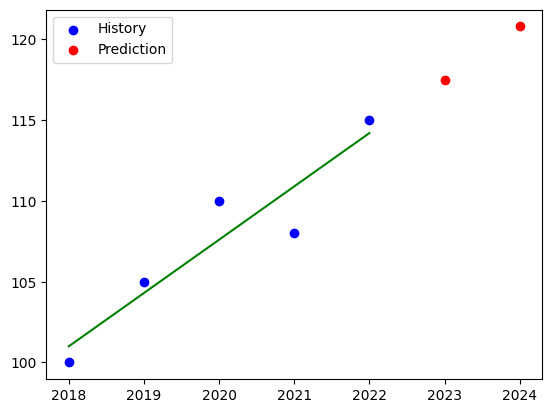

In [2]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 准备数据 ---
# X 必须是二维数组 (几行几列)，y 是一维数组
# 假设是年份 2018-2022
X = np.array([[2018], [2019], [2020], [2021], [2022]])
# 假设是 GDP
y = np.array([100, 105, 110, 108, 115])

# --- 2. 训练模型 ---
model = LinearRegression()
model.fit(X, y)

# --- 3. 预测未来 ---
# 预测 2023 和 2024 年
X_future = np.array([[2023], [2024]])
y_pred = model.predict(X_future)

print("2023-2024 预测值:", y_pred)

# --- 4. 画图展示 (给评委看) ---
plt.scatter(X, y, color='blue', label='History') # 历史点
plt.plot(X, model.predict(X), color='green')     # 趋势线
plt.scatter(X_future, y_pred, color='red', label='Prediction') # 预测点
plt.legend()
plt.show()

In [3]:
from scipy.optimize import linprog

# --- 1. 定义目标函数 (系数) ---
# 我们想求 Max(20x + 30y)
# 也就是求 Min(-20x - 30y) -> 所以系数写成负数
c = [-20, -30] 

# --- 2. 定义约束条件 (不等式) ---
# 约束1: 1x + 2y <= 100 (时间限制)
# 约束2: 1x + 0y <= 80  (A的产量限制)
A = [
    [1, 2], 
    [1, 0]
]
b = [100, 80]

# --- 3. 定义变量范围 ---
# x >= 0, y >= 0 (产量不能是负数)
# (0, None) 表示从0到无穷大
x_bounds = (0, None)
y_bounds = (0, None)

# --- 4. 求解 ---
res = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds, y_bounds], method='highs')

if res.success:
    print("最优生产方案:")
    print(f"生产 A 产品: {res.x[0]:.1f} 个")
    print(f"生产 B 产品: {res.x[1]:.1f} 个")
    # 记得把负号变回来
    print(f"最大利润: {-res.fun:.1f} 元")
else:
    print("无解！")

最优生产方案:
生产 A 产品: 80.0 个
生产 B 产品: 10.0 个
最大利润: 1900.0 元


In [4]:
from scipy.optimize import linprog

# --- 1. 定义目标函数 (系数) ---
# 我们想求 Max(20x + 30y)
# 也就是求 Min(-20x - 30y) -> 所以系数写成负数
c = [-20, -30] 

# --- 2. 定义约束条件 (不等式) ---
# 约束1: 1x + 2y <= 100 (时间限制)
# 约束2: 1x + 0y <= 80  (A的产量限制)
A = [
    [1, 2], 
    [1, 0]
]
b = [100, 80]

# --- 3. 定义变量范围 ---
# x >= 0, y >= 0 (产量不能是负数)
# (0, None) 表示从0到无穷大
x_bounds = (0, None)
y_bounds = (0, None)

# --- 4. 求解 ---
res = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds, y_bounds], method='highs')

if res.success:
    print("最优生产方案:")
    print(f"生产 A 产品: {res.x[0]:.1f} 个")
    print(f"生产 B 产品: {res.x[1]:.1f} 个")
    # 记得把负号变回来
    print(f"最大利润: {-res.fun:.1f} 元")
else:
    print("无解！")

最优生产方案:
生产 A 产品: 80.0 个
生产 B 产品: 10.0 个
最大利润: 1900.0 元


从 A 到 E 的最短路线: ['A', 'C', 'B', 'D', 'E']
总距离: 10


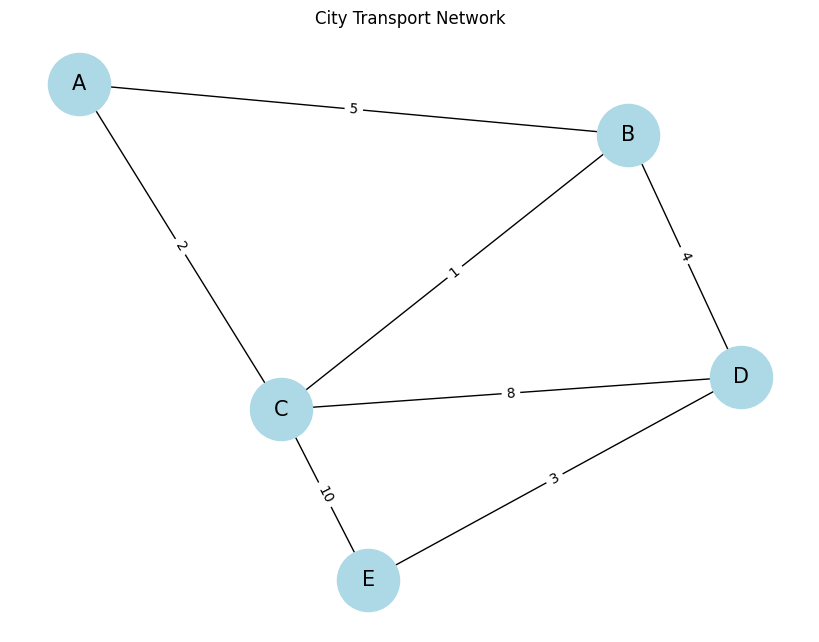

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. 创建一个空图 ---
G = nx.Graph()

# --- 2. 添加路线 (起点, 终点, 距离) ---
# 这里的 weight 可以是距离、时间或成本
edges = [
    ('A', 'B', 5), ('A', 'C', 2),
    ('B', 'D', 4), ('C', 'B', 1),
    ('C', 'D', 8), ('C', 'E', 10),
    ('D', 'E', 3)
]
G.add_weighted_edges_from(edges)

# --- 3. 算法：找最短路径 (Dijkstra算法) ---
path = nx.dijkstra_path(G, source='A', target='E', weight='weight')
length = nx.dijkstra_path_length(G, source='A', target='E', weight='weight')

print(f"从 A 到 E 的最短路线: {path}")
print(f"总距离: {length}")

# --- 4. 画图 (这一步是为了放到论文里) ---
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G) # 自动布局节点位置

# 画节点和边
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=15)
# 把边的权重(距离)标在图上
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("City Transport Network")
plt.show()

In [6]:
# 灵敏度分析极简示例
import numpy as np

def my_model(x):
    return 2 * x + 10  # 假设这是你的复杂模型

base_input = 100
base_output = my_model(base_input)

print(f"原始结果: {base_output}")

# 测试：让输入波动 5%
print("--- 开始灵敏度测试 ---")
for i in range(10):
    # 生成 0.95 到 1.05 之间的随机数
    noise = np.random.uniform(0.95, 1.05) 
    perturbed_input = base_input * noise
    perturbed_output = my_model(perturbed_input)
    
    change_rate = (perturbed_output - base_output) / base_output
    print(f"输入变动 {(noise-1)*100:.2f}%, 结果变动 {change_rate*100:.2f}%")

# 结论：如果输入变了 5%，结果只变了 0.1%，说明模型很稳（Robust）。

原始结果: 210
--- 开始灵敏度测试 ---
输入变动 4.90%, 结果变动 4.66%
输入变动 -0.49%, 结果变动 -0.47%
输入变动 -4.72%, 结果变动 -4.50%
输入变动 -3.92%, 结果变动 -3.74%
输入变动 3.09%, 结果变动 2.94%
输入变动 -1.07%, 结果变动 -1.02%
输入变动 -1.68%, 结果变动 -1.60%
输入变动 -4.52%, 结果变动 -4.30%
输入变动 -3.23%, 结果变动 -3.07%
输入变动 -4.48%, 结果变动 -4.26%


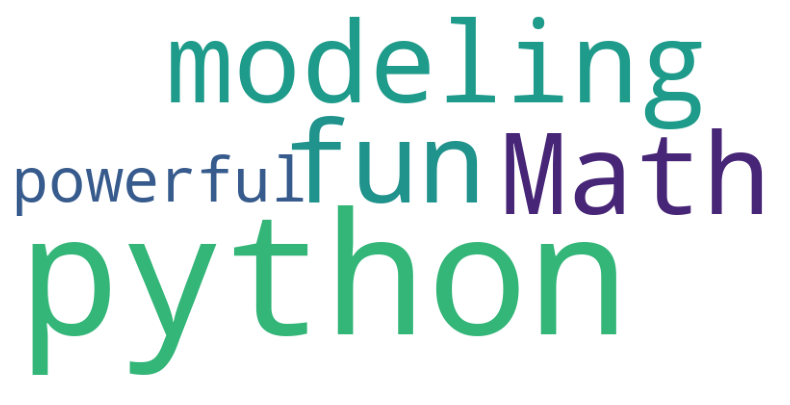

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = "Math modeling is fun and python is powerful python python"

# 生成词云
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

# 画图
plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis('off') # 不显示坐标轴
plt.show()